# AG-HYPOPT · Trial 06

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Registry now holds five trials (warm-up complete): trial_01 0.1907, trial_02 0.2075, trial_03 0.2472, trial_04 0.1987, trial_05 0.1863 (current best). Configs:
- trial_01: sigma_ref 23.97, lr_mu 8.60, lr_gamma 0.960, gamma_anneal 0.384 -> 0.1907
- trial_02: sigma_ref 6.84, lr_mu 25.36, lr_gamma 0.439, gamma_anneal 0.196 -> 0.2075
- trial_03: sigma_ref 16.64, lr_mu 25.03, lr_gamma 0.389, gamma_anneal 0.064 -> 0.2472 (worst)
- trial_04: sigma_ref 6.62, lr_mu 29.41, lr_gamma 0.609, gamma_anneal 0.707 -> 0.1987
- trial_05: sigma_ref 10.72, lr_mu 17.88, lr_gamma 0.846, gamma_anneal 0.604 -> 0.1863 (best)
Two robust facts: (i) mu_fit sits near half of mu_true on every experiment for every config -- the mu term is the objective floor and looks insensitive to these knobs; (ii) gamma_fit recovers well at high transmission but its Trans05 value drives the differences -- strong gamma_anneal (~0.6-0.7: trials 04/05) helps, while near-zero anneal (trial_03, 0.064) collapses it hard. sigma_ref ~7-11 and lr_mu 18-29 have all been tried; the best configs used moderate sigma_ref and lr_mu with strong anneal. TPE now drives the proposals (5/5 warm-up done).


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_06'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (5/5 trials)
ID |     ei | params
 1 | 3.4695 | {"gamma_anneal": 0.6703706167021724, "lr_gamma": 0.4995974124703059, "lr_mu": 17.710682699330537, "sigma_ref": 12.068169427144824}
 2 | 3.6737 | {"gamma_anneal": 0.6598941122810791, "lr_gamma": 0.8801530774470296, "lr_mu": 29.469189054632416, "sigma_ref": 11.095611847770561}
 3 | 1.5806 | {"gamma_anneal": 0.15557944965523104, "lr_gamma": 0.9183040853288101, "lr_mu": 19.612776221443493, "sigma_ref": 14.945358254829472}
 4 | 3.9735 | {"gamma_anneal": 0.6143058491780905, "lr_gamma": 0.8929488628119009, "lr_mu": 15.99144393780724, "sigma_ref": 11.110573798754524}
 5 | 3.7442 | {"gamma_anneal": 0.6652233681199663, "lr_gamma": 0.6313976900041638, "lr_mu": 17.225746126608843, "sigma_ref": 10.035522406491243}
 6 | 3.9609 | {"gamma_anneal": 0.6609668958367043, "lr_gamma": 0.8933240975287313, "lr_mu": 17.737764309023483, "sigma_ref": 9.776111891088007}
 7 | 3.9019 | {"gamma_anneal": 0.6301215645718978, "lr_gamma": 0.7540956968235764

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE is now active (5/5 warm-up). The eight ranked candidates all cluster in roughly the promising region -- moderate sigma_ref (~10-12), lr_mu (~16-19), moderate-to-high lr_gamma (~0.5-0.9) and strong gamma_anneal (~0.55-0.67) -- which is exactly where the two best trials (04, 05) lived and consistent with the physics finding that strong anneal protects the low-transmission gamma estimate. The two unranked slots (9, 10) are exploration draws. I take the proposal with the highest expected improvement, which also sits squarely in this good region: candidate 4 (ei 3.97, gamma_anneal 0.614, lr_gamma 0.893, lr_mu 15.99, sigma_ref 11.11). I choose candidate 4.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4               # highest-EI TPE proposal


chosen: {'gamma_anneal': 0.6143058491780905, 'lr_gamma': 0.8929488628119009, 'lr_mu': 15.99144393780724, 'sigma_ref': 11.110573798754524}
Running  1nW Trans05 ... 

μ 9.39 -> 4.78 | γ 8.5 -> 3.72 | NLL 1.29


Running  1nW Trans20 ... 

μ 17.32 -> 8.75 | γ 8.5 -> 4.17 | NLL 3.19


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 47.17 | γ 14.1 -> 13.69 | NLL 2.93


Running 3nW Trans100 ... 

μ 175.71 -> 79.07 | γ 14.1 -> 13.66 | NLL 2.92



Total: 2.3 min


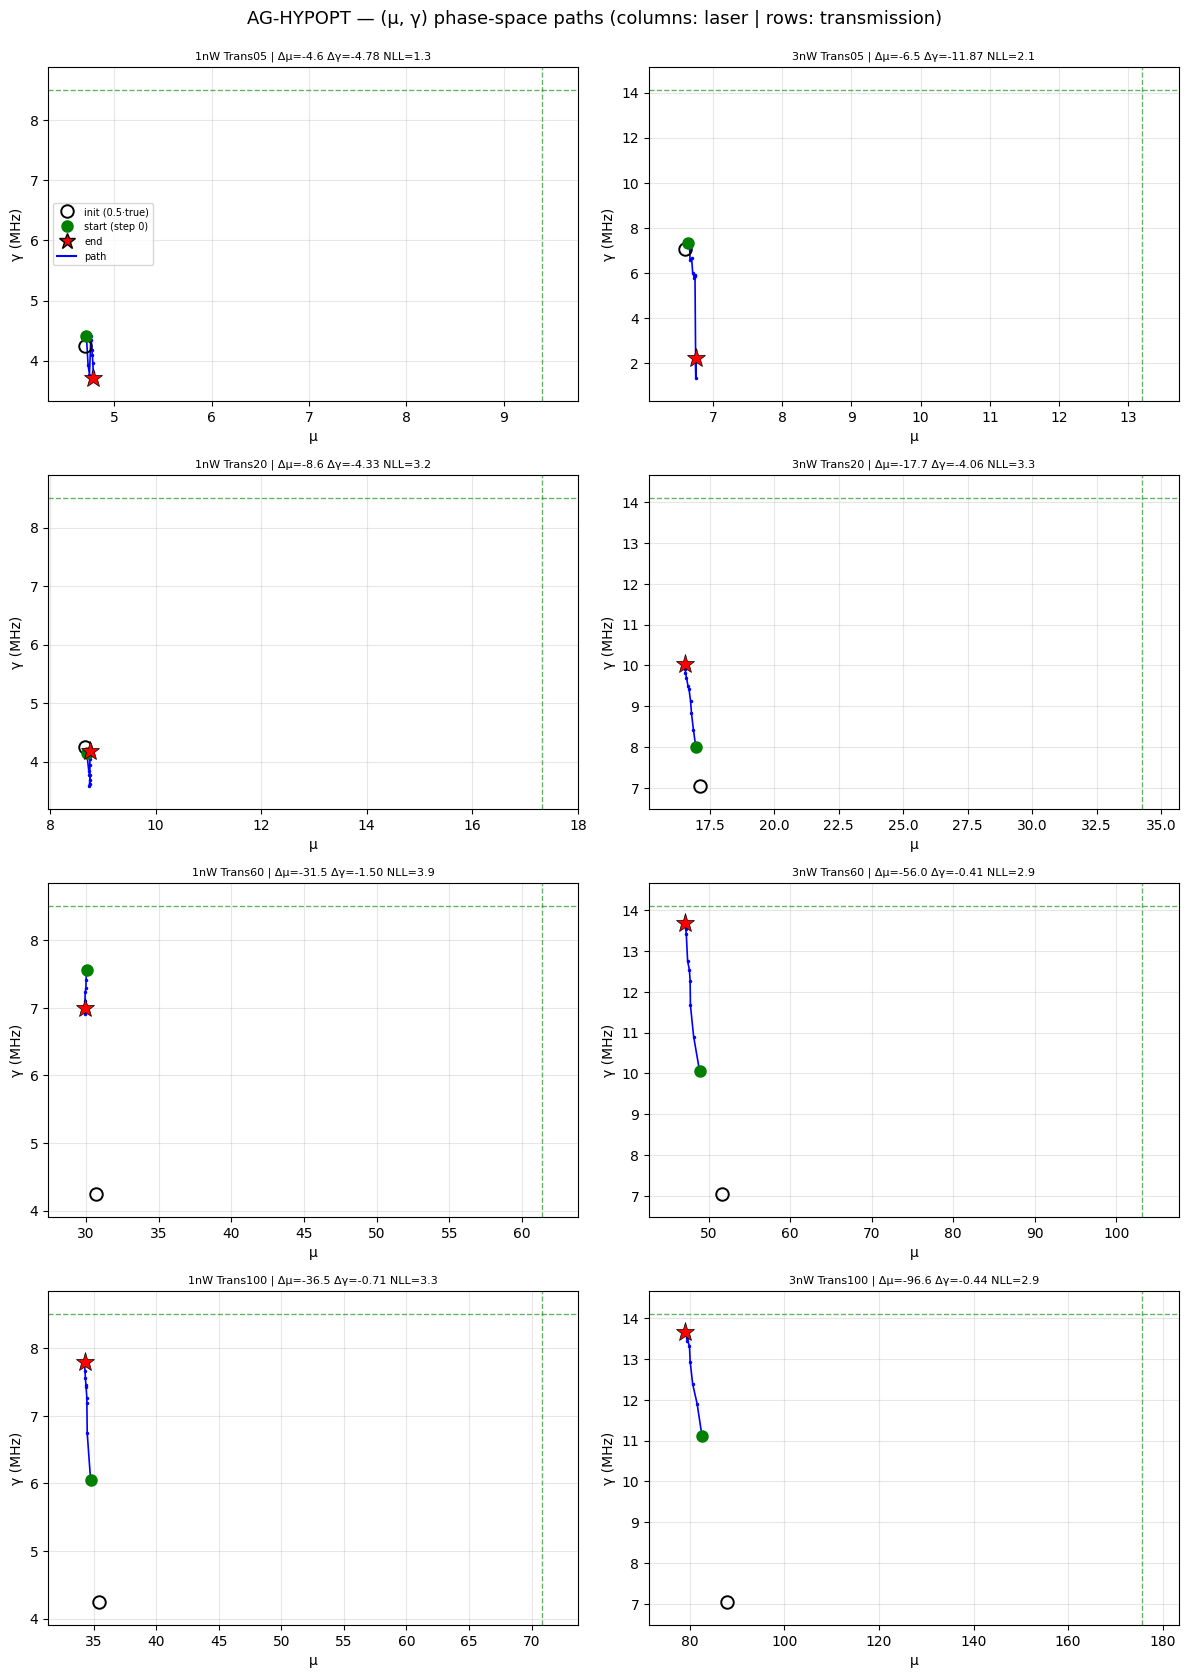

trial finished in 2.4 min
objective = 0.2203 ± 0.0440
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.78   -49.1 |     8.50    3.72   -56.3
1nW Trans20    17.32    8.75   -49.5 |     8.50    4.17   -50.9
1nW Trans60    61.37   29.90   -51.3 |     8.50    7.00   -17.6
1nW Trans100   70.82   34.28   -51.6 |     8.50    7.79    -8.4
3nW Trans05    13.20    6.75   -48.9 |    14.10    2.23   -84.2
3nW Trans20    34.28   16.57   -51.7 |    14.10   10.04   -28.8
3nW Trans60   103.20   47.17   -54.3 |    14.10   13.69    -2.9
3nW Trans100  175.71   79.07   -55.0 |    14.10   13.66    -3.1

μ: RMSE 43.666 (rel 51.5%, bias -32.252) | γ: RMSE 5.025 (rel 41.9%, bias -3.512)


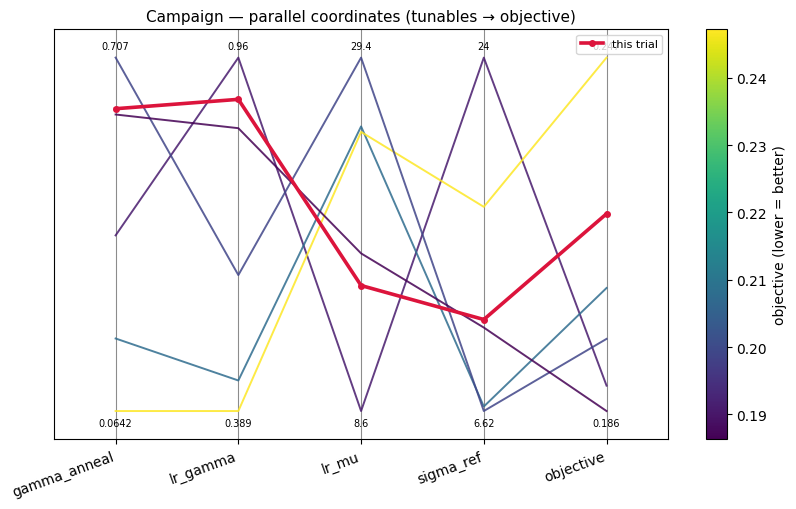

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 06, first TPE-driven trial (5/5 warm-up done); chosen as the highest-EI proposal: sigma_ref 11.11, lr_mu 15.99, lr_gamma 0.893, gamma_anneal 0.614 -- close to the trial_05 recipe that had been best. Result: objective 0.2203 +/- 0.0440, clearly worse than trial_05 (0.1863) and trial_01 (0.1907), runtime 2.4 min. mu_fit is, as always, near half of mu_true and uniform (Delta-mu% -48.9 to -55.0), mu RMSE 43.67 (relative 51.5%, bias -32.3) -- unchanged. gamma_fit is good at high transmission (3 nW Trans60/100: -2.9/-3.1%; 1 nW Trans100: -8.4%) but collapsed at Trans05 (3 nW -84.2%, 1 nW -56.3%) and was poor at 1 nW Trans20 (-50.9%), gamma RMSE 5.03 (relative 41.9%, bias -3.5). So despite the strong anneal (0.614) and a config close to trial_05, gamma recovery at low transmission did not reproduce -- the objective went up mainly through the gamma term.

**Summary:** Trial 06 (highest-EI TPE pick; sigma_ref 11.11, lr_mu 15.99, lr_gamma 0.893, gamma_anneal 0.614) -> objective 0.2203 +/- 0.0440, worse than trial_05 despite a similar recipe; mu unchanged at ~half-truth, gamma collapsed at 3 nW Trans05 (-84.2%).
**Key insight:** A config very close to the best trial did not reproduce its gamma recovery -- the low-transmission gamma estimate is unstable across small hyperparameter changes, so the objective has substantial config-to-config scatter beyond what these four knobs explain.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
No new structural notes; the real-data attractor note from trial_01 still stands.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 06 (highest-EI TPE pick; sigma_ref 11.11, lr_mu 15.99, lr_gamma 0.893, gamma_anneal 0.614): objective 0.2203 +/- 0.0440, worse than trial_05 despite a similar recipe; gamma collapsed at 3 nW Trans05'
KEY_INSIGHT = 'A hyperparameter config very close to the best trial failed to reproduce its gamma recovery -- the low-transmission gamma estimate is unstable across small config changes, adding large scatter to the objective.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_06 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_07.ipynb. Open it and follow its cells from the top.
